# Desbalanceamento

***

In [215]:
!pip install ucimlrepo

In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

# Classes do modelo
from sklearn.linear_model import LogisticRegression

# Funções de avaliação dos modelos
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold


import warnings
warnings.filterwarnings('ignore')

seed = 42

## Análise do conjunto de dados

Abalone -  O Abalone é um molusco gastrópode, herbívoro, que se alimenta de algas marinhas durante aproximadamente 48 meses.

Preveja a idade do abalone a partir de medições físicas. A idade do abalone é determinada cortando a concha através do cone e contando o número de anéis ao microscópio — uma tarefa tediosa e demorada. Outras medições, que são mais fáceis de obter, são usadas para prever a idade.

https://archive.ics.uci.edu/dataset/1/abalone



<img src="https://encrypted-tbn2.gstatic.com/images?q=tbn:ANd9GcRHtXnpfcmMI86SJA49oJ7AvbstTRqKZM_3puNbPoG19GjpYp6O"
alt="Abalone"
width="400" />

In [217]:
# fetch dataset
abalone = fetch_ucirepo(id=1)

# data (as pandas dataframes)
X = abalone.data.features
y = abalone.data.targets

df = pd.concat([X, y], axis=1)
df

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


### Name / Data Type / Measurement Unit / Description
Rings / integer / -- / +1.5 gives the age in years (TARGET)

Sex / nominal / -- / M, F, and I (infant)

Length / continuous / mm / Longest shell measurement

Diameter	/ continuous / mm / perpendicular to length

Height / continuous / mm / with meat in shell

Whole weight / continuous / grams / whole abalone

Shucked weight / continuous	 / grams / weight of meat

Viscera weight / continuous / grams / gut weight (after bleeding)

Shell weight / continuous / grams / after being dried

In [218]:
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


### Visualizando a distribuição dos dados por classe

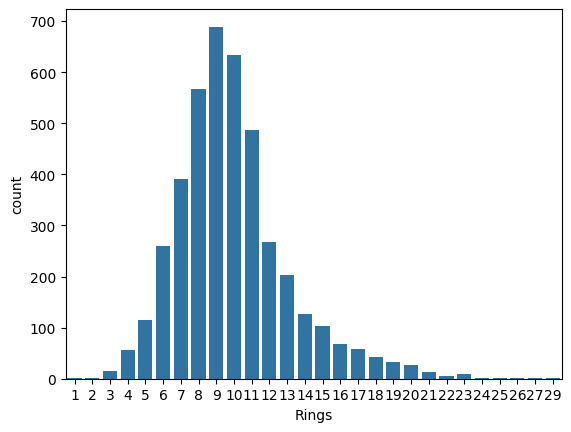

In [219]:
sns.countplot(x="Rings", data=df)
plt.show()

In [220]:
var_min = 4
var_max = 14

### Separando o conjunto de dados

(3796, 9)


<Axes: xlabel='Rings', ylabel='Rings'>

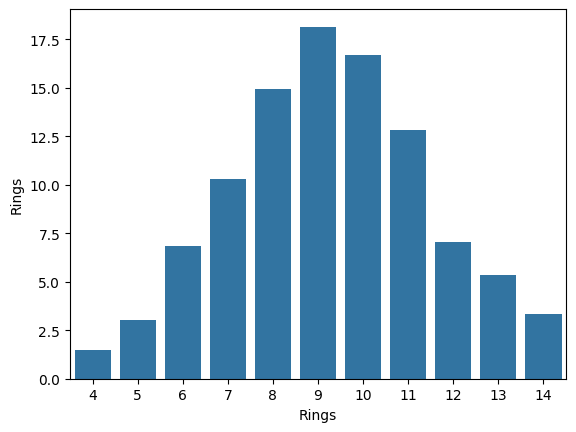

In [221]:
dfFiltrado =  df.loc[(df["Rings"]>=var_min) & (df["Rings"]<=var_max)]

print(dfFiltrado.shape)

#percentual
sns.barplot(x="Rings", y="Rings",  data=dfFiltrado,  estimator=lambda x: len(x) / len(dfFiltrado) * 100)

In [222]:
#Convertendo atributo sexo
dfFiltrado['Sex'] = pd.factorize(dfFiltrado['Sex'])[0]
dfFiltrado

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
1,0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,2,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
5,2,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.1200,8
...,...,...,...,...,...,...,...,...,...
4172,1,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,0,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,0,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,1,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [223]:
X = dfFiltrado.iloc[:,0:8]
y = dfFiltrado.iloc[:,8]

#Separando o conjunto de dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=seed)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (2657, 8)
Shape de X_test: (1139, 8)
Shape de y_train: (2657,)
Shape de y_test: (1139,)


### Treinando o modelo

In [224]:
model = LogisticRegression(random_state=seed)

#treinando o modelo
model.fit(X_train, y_train)

#predição
y_pred = model.predict(X_test)

#Resultados do classificador
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00        17
           5       0.33      0.14      0.20        35
           6       0.32      0.26      0.28        78
           7       0.32      0.45      0.38       117
           8       0.31      0.37      0.34       170
           9       0.27      0.40      0.32       207
          10       0.26      0.39      0.32       190
          11       0.34      0.25      0.29       146
          12       0.00      0.00      0.00        80
          13       0.00      0.00      0.00        61
          14       0.00      0.00      0.00        38

    accuracy                           0.29      1139
   macro avg       0.20      0.21      0.19      1139
weighted avg       0.25      0.29      0.26      1139



In [225]:
from sklearn.neural_network import MLPClassifier

# Definindo o modelo MLP
model = MLPClassifier(hidden_layer_sizes=(300), activation='relu', random_state=seed)

# Treinando o modelo
model.fit(X_train, y_train)

# Predição
y_pred = model.predict(X_test)

# Resultados do classificador
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           4       0.52      0.71      0.60        17
           5       0.36      0.26      0.30        35
           6       0.36      0.29      0.32        78
           7       0.29      0.33      0.31       117
           8       0.35      0.36      0.36       170
           9       0.27      0.41      0.32       207
          10       0.22      0.29      0.25       190
          11       0.32      0.23      0.27       146
          12       0.33      0.04      0.07        80
          13       0.12      0.08      0.10        61
          14       0.00      0.00      0.00        38

    accuracy                           0.29      1139
   macro avg       0.29      0.27      0.26      1139
weighted avg       0.28      0.29      0.27      1139



## Undersampling (Random)

- Undersampling: reduz o número de amostras da classe **majoritária** para balancear o dataset.

Lembre de instalar o `imblearn` (caso o ambiente não contenha):

In [226]:
from imblearn.under_sampling import RandomUnderSampler

(627, 8)
(627,)


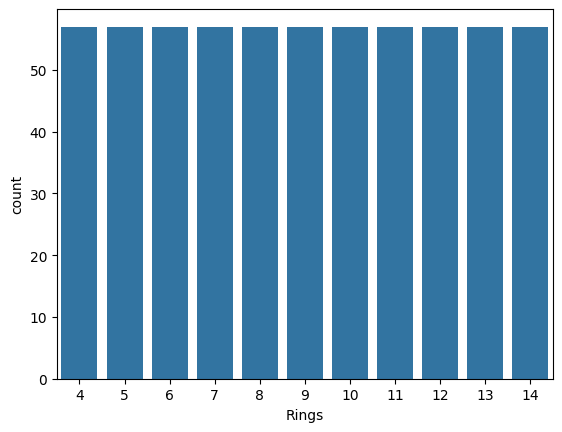

In [227]:
#Aplicando RandomUnderSampler
X = dfFiltrado.iloc[:,0:8]
y = dfFiltrado.iloc[:,8]

rus = RandomUnderSampler(random_state=seed)
X_rus, y_rus = rus.fit_resample(X, y)

print(X_rus.shape)
print(y_rus.shape)

# Visualizando a distribuição dos dados após o undersampling
sns.countplot(x=y_rus)
plt.show()

In [228]:
X_train, X_test, y_train, y_test = train_test_split(X_rus, y_rus, test_size=0.3, stratify=y_rus, random_state=seed)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (438, 8)
Shape de X_test: (189, 8)
Shape de y_train: (438,)
Shape de y_test: (189,)


In [229]:
model = LogisticRegression(random_state=seed)

#treinando o modelo
model.fit(X_train, y_train)

#predição
y_pred = model.predict(X_test)

#Resultados do classificador
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           4       0.57      1.00      0.72        17
           5       0.33      0.12      0.17        17
           6       0.42      0.76      0.54        17
           7       0.33      0.22      0.27        18
           8       0.17      0.18      0.17        17
           9       0.06      0.06      0.06        17
          10       0.00      0.00      0.00        18
          11       0.05      0.06      0.06        17
          12       0.19      0.24      0.21        17
          13       0.20      0.35      0.26        17
          14       0.20      0.06      0.09        17

    accuracy                           0.28       189
   macro avg       0.23      0.28      0.23       189
weighted avg       0.23      0.28      0.23       189



In [230]:
# Definindo o modelo MLP
model = MLPClassifier(hidden_layer_sizes=(300), activation='relu', random_state=seed)

# Treinando o modelo
model.fit(X_train, y_train)

# Predição
y_pred = model.predict(X_test)

# Resultados do classificador
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           4       0.73      0.94      0.82        17
           5       0.64      0.41      0.50        17
           6       0.43      0.53      0.47        17
           7       0.47      0.44      0.46        18
           8       0.31      0.47      0.37        17
           9       0.05      0.06      0.05        17
          10       0.00      0.00      0.00        18
          11       0.15      0.18      0.16        17
          12       0.19      0.35      0.24        17
          13       0.50      0.06      0.11        17
          14       0.23      0.18      0.20        17

    accuracy                           0.33       189
   macro avg       0.33      0.33      0.31       189
weighted avg       0.33      0.33      0.31       189



## Undersampling (CondensedNN)

In [231]:
from imblearn.under_sampling import CondensedNearestNeighbour

(3796, 8)
(3796,)
(255, 8)
(255,)


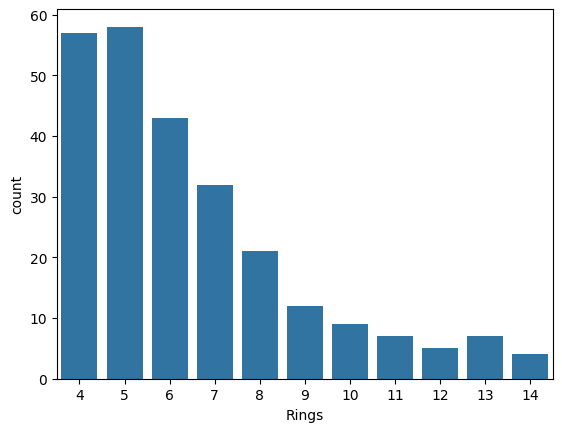

In [232]:
#Aplicando CondensedNN
X = dfFiltrado.iloc[:,0:8]
y = dfFiltrado.iloc[:,8]

print(X.shape)
print(y.shape)

cnn = CondensedNearestNeighbour(random_state=seed)
X_cnn, y_cnn = cnn.fit_resample(X, y)

print(X_cnn.shape)
print(y_cnn.shape)

# Visualizando a distribuição dos dados após o undersampling
sns.countplot(x=y_cnn)
plt.show()

In [233]:
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y_cnn, test_size=0.3, stratify=y_cnn, random_state=seed)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (178, 8)
Shape de X_test: (77, 8)
Shape de y_train: (178,)
Shape de y_test: (77,)


In [234]:
model = LogisticRegression(random_state=seed)

#treinando o modelo
model.fit(X_train, y_train)

#predição
y_pred = model.predict(X_test)

#Resultados do classificador
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           4       0.44      1.00      0.61        17
           5       0.21      0.28      0.24        18
           6       0.00      0.00      0.00        13
           7       0.18      0.20      0.19        10
           8       0.00      0.00      0.00         6
           9       0.00      0.00      0.00         4
          10       0.00      0.00      0.00         3
          11       0.00      0.00      0.00         2
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         1

    accuracy                           0.31        77
   macro avg       0.08      0.13      0.09        77
weighted avg       0.17      0.31      0.21        77



In [235]:
# Definindo o modelo MLP
model = MLPClassifier(hidden_layer_sizes=(300), activation='relu', random_state=seed)

# Treinando o modelo
model.fit(X_train, y_train)

# Predição
y_pred = model.predict(X_test)

# Resultados do classificador
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           4       0.53      0.94      0.68        17
           5       0.19      0.28      0.23        18
           6       0.00      0.00      0.00        13
           7       0.25      0.20      0.22        10
           8       0.11      0.17      0.13         6
           9       0.00      0.00      0.00         4
          10       0.00      0.00      0.00         3
          11       0.00      0.00      0.00         2
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         1

    accuracy                           0.31        77
   macro avg       0.10      0.14      0.11        77
weighted avg       0.20      0.31      0.24        77



----------------------------------------------------------------
## SMOTE

No pacote `imblearn` que lida com problemas de desbalanceamento de classes em conjuntos de dados, também temos tecnicas de oversampling:

- SMOTE (oversampling): que gera novas amostras sintéticas da classe **minoritária**, em vez de simplesmente duplicar as amostras existentes.

In [236]:
# !pip install imblearn

In [237]:
from imblearn.over_sampling import SMOTE

### Aplicando o SMOTE

In [238]:
smt = SMOTE(random_state=seed, sampling_strategy='auto') # k_neighbors por padrão é 5

#Aplicando RandomUnderSampler
X = dfFiltrado.iloc[:,0:8]
y = dfFiltrado.iloc[:,8]
X_smt, y_smt = smt.fit_resample(X, y)

### Gerando um novo dataset (balanceado)

Criando um novo dataset com as amostras balanceadas...

(7579, 9)


<Axes: xlabel='Rings', ylabel='Rings'>

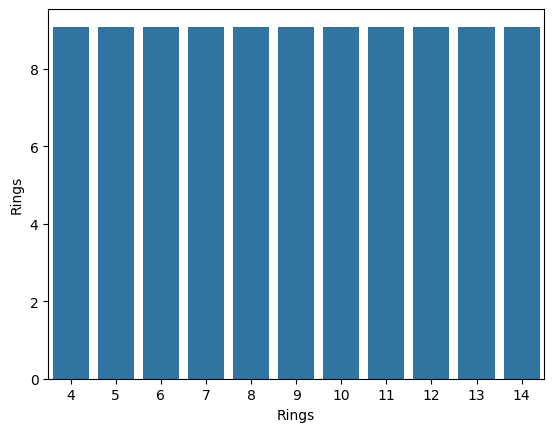

In [239]:
df_SMOTE = pd.DataFrame(X_smt, columns=X_train.columns)
df_SMOTE.insert(0, 'Rings', y_smt)  # Inserir 'Rings' na posição 0

print(df_SMOTE.shape)

#percentual
sns.barplot(x="Rings", y="Rings",  data=df_SMOTE,  estimator=lambda x: len(x) / len(df_SMOTE) * 100)

In [240]:
df_SMOTE.describe()

,Rings,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
count,7579.000000,7579.000000,7579.000000,7579.000000,7579.000000,7579.000000,7579.000000,7579.000000,7579.000000
mean,9.000000,1.096451,0.479297,0.371307,0.126525,0.704104,0.305112,0.154022,0.203222
std,3.162486,0.854443,0.149157,0.122688,0.047265,0.527836,0.237198,0.117452,0.147997
min,4.000000,0.000000,0.130000,0.095000,0.000000,0.010500,0.005000,0.000500,0.003500
25%,6.000000,0.000000,0.370000,0.275000,0.090000,0.225500,0.097574,0.048500,0.070000
50%,9.000000,1.000000,0.505000,0.390178,0.130000,0.629500,0.266000,0.137000,0.186000
75%,12.000000,2.000000,0.600000,0.470173,0.160000,1.087560,0.465158,0.236215,0.310000
max,14.000000,2.000000,0.815000,0.650000,1.130000,2.779500,1.488000,0.760000,0.797500


In [241]:
X = df_SMOTE.iloc[:,1:9]
y = df_SMOTE.iloc[:,0]

#Separando o conjunto de dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=seed)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (5305, 8)
Shape de X_test: (2274, 8)
Shape de y_train: (5305,)
Shape de y_test: (2274,)


### Treinando o modelo

In [242]:
model = LogisticRegression(random_state=seed)

#treinando o modelo
model.fit(X_train, y_train)

#predição
y_pred = model.predict(X_test)

#Resultados do classificador
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           4       0.64      0.86      0.73       206
           5       0.48      0.45      0.47       207
           6       0.36      0.43      0.39       207
           7       0.20      0.21      0.21       207
           8       0.28      0.30      0.29       207
           9       0.19      0.19      0.19       206
          10       0.17      0.08      0.11       207
          11       0.25      0.35      0.29       207
          12       0.24      0.11      0.15       207
          13       0.28      0.14      0.18       206
          14       0.28      0.46      0.35       207

    accuracy                           0.33      2274
   macro avg       0.31      0.33      0.31      2274
weighted avg       0.31      0.33      0.31      2274



In [243]:
# Definindo o modelo MLP
model = MLPClassifier(hidden_layer_sizes=(300), activation='relu', random_state=seed)

# Treinando o modelo
model.fit(X_train, y_train)

# Predição
y_pred = model.predict(X_test)

# Resultados do classificador
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           4       0.73      0.79      0.76       206
           5       0.50      0.52      0.51       207
           6       0.39      0.40      0.40       207
           7       0.32      0.34      0.33       207
           8       0.34      0.25      0.29       207
           9       0.21      0.29      0.24       206
          10       0.32      0.03      0.05       207
          11       0.24      0.37      0.29       207
          12       0.18      0.20      0.19       207
          13       0.31      0.36      0.33       206
          14       0.36      0.29      0.32       207

    accuracy                           0.35      2274
   macro avg       0.35      0.35      0.34      2274
weighted avg       0.35      0.35      0.34      2274



--------------------

Experimente com uma seleção diferente da base.

Que tal var_min = 4 e var_max = 12?

## Cuidado com viés

Usar o smote em todo o dataset ou apenas na porção de treinamento?

In [244]:
X = dfFiltrado.iloc[:,0:8]
y = dfFiltrado.iloc[:,8]
#Separando o conjunto de dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=seed)

In [245]:
smt = SMOTE(random_state=seed, sampling_strategy='auto')

X_smt_tr, y_smt_tr = smt.fit_resample(X_train, y_train)
X_smt_tr

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,0,0.680000,0.530000,0.205000,1.496000,0.582500,0.337000,0.465000
1,1,0.460000,0.375000,0.120000,0.460500,0.177500,0.110000,0.150000
2,0,0.625000,0.480000,0.145000,1.085000,0.464500,0.244500,0.327000
3,1,0.465000,0.355000,0.115000,0.470500,0.195500,0.118000,0.126000
4,2,0.375000,0.275000,0.090000,0.238000,0.107500,0.054500,0.070000
...,...,...,...,...,...,...,...,...
5297,0,0.659377,0.510935,0.166559,1.628897,0.759648,0.357368,0.392656
5298,0,0.674829,0.525568,0.202784,1.505381,0.605917,0.342097,0.453107
5299,0,0.503994,0.392321,0.152987,0.771284,0.255851,0.197995,0.209458
5300,1,0.594051,0.475615,0.165000,1.069120,0.437939,0.209536,0.315922


(5302, 9)


<Axes: xlabel='Rings', ylabel='Rings'>

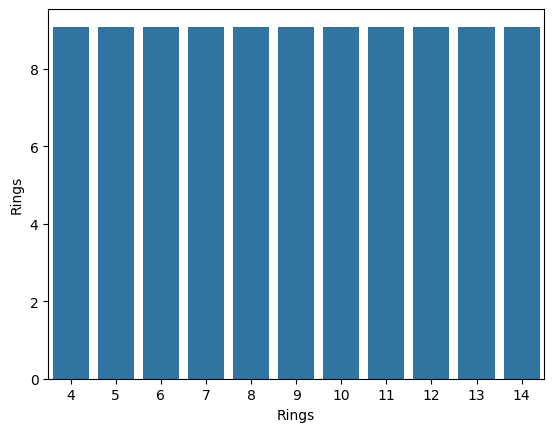

In [246]:
df_SMOTE = pd.DataFrame(X_smt_tr, columns=X_train.columns)
df_SMOTE.insert(0, 'Rings', y_smt_tr)  # Inserir 'Rings' na posição 0

print(df_SMOTE.shape)

#percentual
sns.barplot(x="Rings", y="Rings",  data=df_SMOTE,  estimator=lambda x: len(x) / len(df_SMOTE) * 100)

In [247]:
df_SMOTE.describe()

,Rings,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
count,5302.000000,5302.000000,5302.000000,5302.000000,5302.000000,5302.000000,5302.000000,5302.000000,5302.000000
mean,9.000000,1.100339,0.478401,0.370190,0.126453,0.696795,0.300947,0.152526,0.201530
std,3.162576,0.850959,0.147514,0.121554,0.045406,0.522843,0.235903,0.116555,0.146601
min,4.000000,0.000000,0.130000,0.095000,0.000000,0.010500,0.005000,0.000500,0.003500
25%,6.000000,0.000000,0.367205,0.275000,0.090000,0.222583,0.096000,0.046884,0.069208
50%,9.000000,1.000000,0.503930,0.390000,0.130000,0.623221,0.259500,0.136693,0.185000
75%,12.000000,2.000000,0.595285,0.470000,0.160106,1.060938,0.454375,0.231000,0.305500
max,14.000000,2.000000,0.815000,0.650000,0.515000,2.779500,1.488000,0.760000,0.797500


In [248]:
model = LogisticRegression(random_state=seed)

print(X_smt_tr.shape)
print(y_smt_tr.shape)

#treinando o modelo
model.fit(X_smt_tr, y_smt_tr)

#predição
y_pred = model.predict(X_test)

#Resultados do classificador
print(classification_report(y_test, y_pred))

(5302, 8)
(5302,)
              precision    recall  f1-score   support

           4       0.46      0.94      0.62        17
           5       0.20      0.34      0.26        35
           6       0.34      0.45      0.39        78
           7       0.23      0.26      0.25       117
           8       0.29      0.29      0.29       170
           9       0.32      0.23      0.27       207
          10       0.27      0.12      0.17       190
          11       0.26      0.32      0.29       146
          12       0.00      0.00      0.00        80
          13       0.11      0.15      0.12        61
          14       0.13      0.42      0.20        38

    accuracy                           0.25      1139
   macro avg       0.24      0.32      0.26      1139
weighted avg       0.25      0.25      0.24      1139



In [249]:
from sklearn.neural_network import MLPClassifier

# Definindo o modelo MLP
model = MLPClassifier(hidden_layer_sizes=(300), activation='relu', random_state=seed)

# Treinando o modelo
model.fit(X_smt_tr, y_smt_tr)

# Predição
y_pred = model.predict(X_test)

# Resultados do classificador
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           4       0.52      0.88      0.65        17
           5       0.32      0.46      0.38        35
           6       0.33      0.22      0.26        78
           7       0.28      0.42      0.33       117
           8       0.32      0.37      0.34       170
           9       0.32      0.20      0.25       207
          10       0.26      0.13      0.17       190
          11       0.25      0.23      0.24       146
          12       0.08      0.07      0.08        80
          13       0.18      0.16      0.17        61
          14       0.10      0.39      0.16        38

    accuracy                           0.25      1139
   macro avg       0.27      0.32      0.28      1139
weighted avg       0.27      0.25      0.25      1139

